In [7]:
from os.path import join
import numpy as np
import matplotlib.pyplot as plt
import galsim as gs
import jax

from kl_pipe.tng import (
  TNG50MockData,
  TNG50Galaxy,
  TNGDataVectorGenerator,
  TNGRenderConfig,
  FiberDataVector
)
from kl_pipe.parameters import ImagePars
from kl_pipe.spectral import CubePars, FiberPars, make_spectral_config, halpha_vac_line, desi_z_R

HOME_DIR = '/jet/home/xwang30/'
temp_dir = HOME_DIR + 'kl_roman_pipe/data'
template_dir = HOME_DIR + 'kl-tools/data'

In [2]:
jax.config.update('jax_enable_x64', True)

In [3]:
tng = TNG50Galaxy(index=1)
galaxy = tng.get_galaxy()
# tng = TNG50MockData(use_gold=True)
# galaxy = tng[0]
psfscale = 1.028993969962188
psf = gs.Airy(lam_over_diam=1.0/psfscale, scale_unit=gs.arcsec)
params = {'theta_int': 0.,
          'cosi': 0.25,
          'x0': 0.,
          'y0': 0.,
          'g1': 0.,
          'g2': 0.,}
z = 0.3

In [4]:
image_pars = ImagePars(shape=(96, 96), pixel_scale=0.2637/2, indexing='ij')
render_cfg = TNGRenderConfig(image_pars=image_pars,
                             band='r',                      # Photometric band: 'g', 'r', 'i', 'u', 'z'
                             use_dusted=True,               # Use dust-attenuated luminosities
                             center_on_peak=True,           # Center on luminosity peak (vs subhalo center)
                             use_native_orientation=False,   # Use TNG's native inc/PA (or custom if False)
                             pars=params,                     # Custom orientation params (if use_native_orientation=False)
                             use_cic_gridding=True,         # Cloud-in-Cell (True) vs Nearest-Grid-Point (False)
                             target_redshift=z,           # Scale to z=0.7 for Roman-like sub-arcsec obs (TNG native z~0.01)
                             preserve_gas_stellar_offset=True,  # Keep physical gas-stellar misalignment (default)
                             psf=psf,
                             )
render_cfg_clean = TNGRenderConfig(image_pars=image_pars,
                             band='r',                      # Photometric band: 'g', 'r', 'i', 'u', 'z'
                             use_dusted=True,               # Use dust-attenuated luminosities
                             center_on_peak=True,           # Center on luminosity peak (vs subhalo center)
                             use_native_orientation=False,   # Use TNG's native inc/PA (or custom if False)
                             pars=params,                     # Custom orientation params (if use_native_orientation=False)
                             use_cic_gridding=True,         # Cloud-in-Cell (True) vs Nearest-Grid-Point (False)
                             target_redshift=z,           # Scale to z=0.7 for Roman-like sub-arcsec obs (TNG native z~0.01)
                             preserve_gas_stellar_offset=True,  # Keep physical gas-stellar misalignment (default)
                             )

In [21]:
spec_cfg = make_spectral_config(lines=[halpha_vac_line()],
                                R_func=desi_z_R)

cube_pars_phot = CubePars.from_range(image_pars, 565.5, 717, 5.)
cube_pars_spec = CubePars.from_range(image_pars, 851., 855.81, 0.08)

line_fluxes = {'Ha': 1e-16}
line_continua = {'Ha': 1e-16}

obs_cfg_phot = {'INSTNAME': "CTIO/DECam", 'OBSTYPE': 0, 'NAXIS': 2,
    'NAXIS1': 48, 'NAXIS2': 48, 'PIXSCALE': 0.2637, 'PSFTYPE': "none",
    'PSFFWHM': 1.0, 'DIAMETER': 378.2856, 'GAIN': 4.0,
    'NOISETYP': 'ccd', 'RDNOISE': 2.6, 'ADDNOISE': False,
    'BANDPASS': join(template_dir, "Bandpass/CTIO/DECam.r.dat"), 
    'SKYLEVEL': 44.54, 'EXPTIME': 60
}
obs_cfg_spec = {'INSTNAME': "DESI", 'OBSTYPE': 1,
    'SKYMODEL': join(template_dir, "Skyspectra/spec-sky.dat"), 'PSFTYPE': "airy_fwhm", 
    'PSFFWHM': 1.0, 'DIAMETER': 332.42, 'EXPTIME': 180, 'GAIN': 1.0,
    'NOISETYP': 'ccd', 'ADDNOISE': False, 'FIBERRAD': 0.75, 'FIBRBLUR': 3.4,
    'BANDPASS': join(template_dir, "Bandpass/DESI/z.dat"),
    'RDNOISE': 2.6, 'FIBERDX': 1.5, 'FIBERDY': 0.0
}

fiber_pars_phot = FiberPars.from_cube_pars(cube_pars_phot, obs_cfg_phot)
fiber_pars_spec = FiberPars.from_cube_pars(cube_pars_spec, obs_cfg_spec)

In [22]:
gen_phot = FiberDataVector(galaxy, fiber_pars_phot)
gen_spec = FiberDataVector(galaxy, fiber_pars_spec)

In [23]:
cube_phot = gen_phot.generate_cube(render_cfg_clean,
                         cube_pars_phot,
                         spec_cfg,
                         line_fluxes=line_fluxes,
                         line_continua=line_continua,
                         )
cube_spec = gen_spec.generate_cube(render_cfg_clean,
                         cube_pars_spec,
                         spec_cfg,
                         line_fluxes=line_fluxes,
                         line_continua=line_continua,
                         )

In [24]:
cube_phot.shape

(96, 96, 31)

In [26]:
# img = gen_phot.fiber_observe_cube(cube_phot)
spec, _ = gen_spec.fiber_observe_cube(cube_spec)

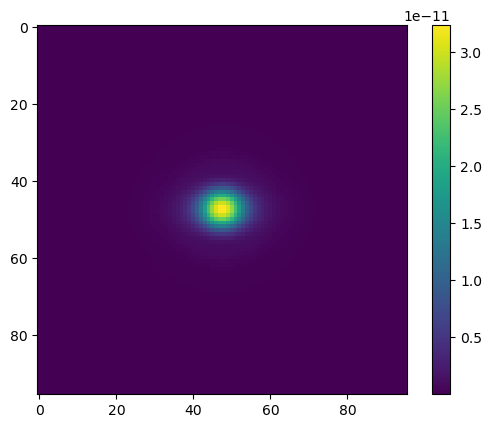

In [19]:
plt.imshow(img)
plt.colorbar()

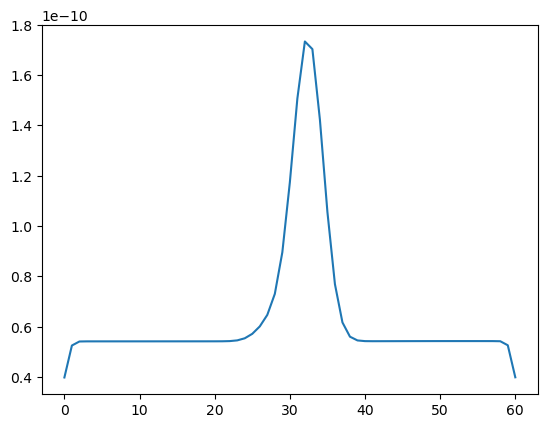

In [27]:
plt.plot(spec)

In [20]:
intensity, var_i = gen_phot.generate_intensity_map(render_cfg, snr=900, seed=42)
intensity_clean, var_i_c = gen_phot.generate_intensity_map(render_cfg_clean, snr=None, seed=42)
velocity, var_v = gen_phot.generate_velocity_map(render_cfg, snr=900, seed=42)
velocity_clean, var_v = gen_phot.generate_velocity_map(render_cfg, snr=900, seed=42, intensity_map=intensity_clean)
velocity_nopsf, _ = gen_phot.generate_velocity_map(render_cfg_clean, snr=900, seed=42, intensity_map=intensity_clean)

/var/tmp/ipykernel_71572/788328221.py:3: UserWarning: PSF set but no intensity_map provided to generate_velocity_map. Generating intensity internally (less efficient).
  velocity, var_v = gen_phot.generate_velocity_map(render_cfg, snr=900, seed=42)


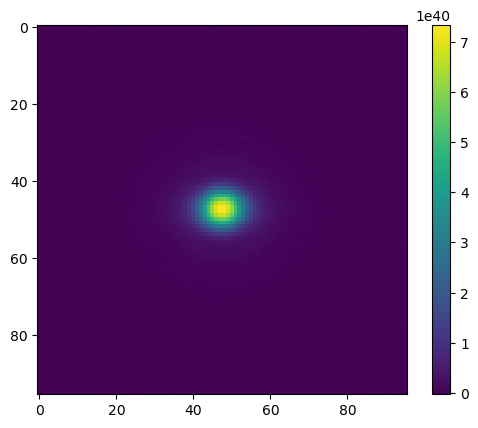

In [22]:
plt.imshow(intensity)
plt.colorbar()

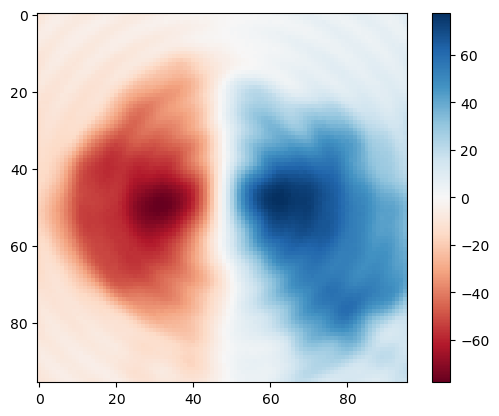

In [9]:
plt.imshow(velocity, cmap='RdBu')
plt.colorbar()